# Artificial Neural Networks
## Assignment 3
### Saad Karim   22P-9277
### Task 0: Understand the Working Example

In [216]:
import numpy as np
from matplotlib import pyplot as plt

In [217]:
def conv2d(image, kernel):
    kernel_height, kernel_width = kernel.shape
    image_height, image_width   = image.shape
    output_height = image_height - kernel_height + 1
    output_width = image_width - kernel_width + 1
    output = np.zeros((output_height, output_width))
    
    for i in range(output_height):
        for j in range(output_width):
            region = image[i:i+kernel_height, j:j+kernel_width]
            output[i, j] = np.sum(region * kernel)
    
    return output

In [218]:
def relu(x):
    return np.maximum(0, x)

In [219]:
def max_pooling(image, pool_size=2):
    image_height, image_width = image.shape

    output_height = (image_height + pool_size - 1) // pool_size
    output_width = (image_width + pool_size - 1) // pool_size
    output = np.zeros((output_height, output_width))

    for i in range(output_height):
        for j in range(output_width):
            start_i = i * pool_size
            start_j = j * pool_size
            end_i = min(start_i + pool_size, image_height)
            end_j = min(start_j + pool_size, image_width)

            region = image[start_i:end_i, start_j:end_j]
            output[i, j] = np.max(region)

    return output

In [220]:
def avg_pooling(image, pool_size=2):
    image_height, image_width = image.shape

    output_height = (image_height + pool_size - 1) // pool_size
    output_width = (image_width + pool_size - 1) // pool_size
    output = np.zeros((output_height, output_width))

    for i in range(output_height):
        for j in range(output_width):
            start_i = i * pool_size
            start_j = j * pool_size
            end_i = min(start_i + pool_size, image_height)
            end_j = min(start_j + pool_size, image_width)

            region = image[start_i:end_i, start_j:end_j]
            output[i, j] = np.average(region)

    return output

In [221]:
def dense_layer(inputs, weights, bias):
    return np.dot(inputs, weights) + bias

def softmax(x):
    exp_x = np.exp(x - np.max(x))
    return exp_x / np.sum(exp_x)

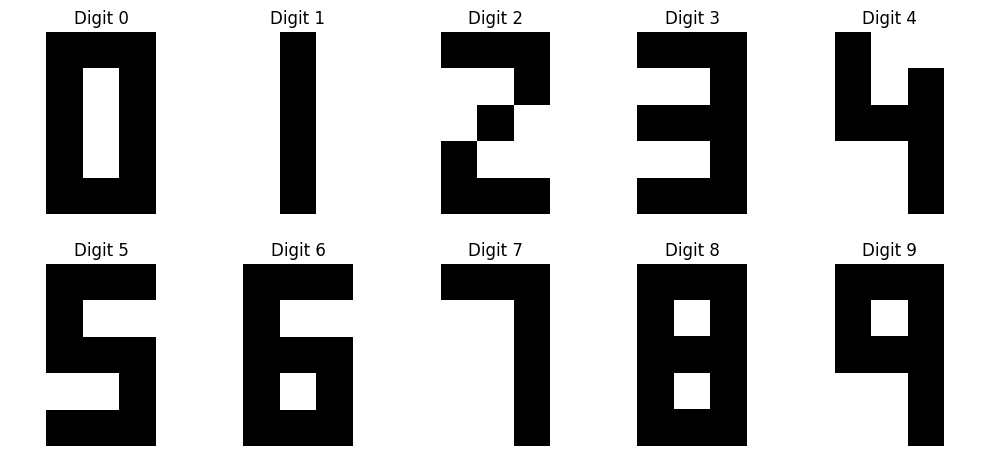

In [222]:
dataset = [
    np.array([
        [0, 1, 1, 1, 0],
        [0, 1, 0, 1, 0],
        [0, 1, 0, 1, 0],
        [0, 1, 0, 1, 0],
        [0, 1, 1, 1, 0]
    ]),
    np.array([
        [0, 0, 1, 0, 0],
        [0, 0, 1, 0, 0],
        [0, 0, 1, 0, 0],
        [0, 0, 1, 0, 0],
        [0, 0, 1, 0, 0]
    ]),
    np.array([
        [0, 1, 1, 1, 0],
        [0, 0, 0, 1, 0],
        [0, 0, 1, 0, 0],
        [0, 1, 0, 0, 0],
        [0, 1, 1, 1, 0]
    ]),
    np.array([
        [0, 1, 1, 1, 0],
        [0, 0, 0, 1, 0],
        [0, 1, 1, 1, 0],
        [0, 0, 0, 1, 0],
        [0, 1, 1, 1, 0]
    ]),
    np.array([
        [0, 1, 0, 0, 0],
        [0, 1, 0, 1, 0],
        [0, 1, 1, 1, 0],
        [0, 0, 0, 1, 0],
        [0, 0, 0, 1, 0]
    ]),
    np.array([
        [0, 1, 1, 1, 0],
        [0, 1, 0, 0, 0],
        [0, 1, 1, 1, 0],
        [0, 0, 0, 1, 0],
        [0, 1, 1, 1, 0]
    ]),
    np.array([
        [0, 1, 1, 1, 0],
        [0, 1, 0, 0, 0],
        [0, 1, 1, 1, 0],
        [0, 1, 0, 1, 0],
        [0, 1, 1, 1, 0]
    ]),
    np.array([
        [0, 1, 1, 1, 0],
        [0, 0, 0, 1, 0],
        [0, 0, 0, 1, 0],
        [0, 0, 0, 1, 0],
        [0, 0, 0, 1, 0]
    ]),
    np.array([
        [0, 1, 1, 1, 0],
        [0, 1, 0, 1, 0],
        [0, 1, 1, 1, 0],
        [0, 1, 0, 1, 0],
        [0, 1, 1, 1, 0]
    ]),
    np.array([
        [0, 1, 1, 1, 0],
        [0, 1, 0, 1, 0],
        [0, 1, 1, 1, 0],
        [0, 0, 0, 1, 0],
        [0, 0, 0, 1, 0]
    ])
    
]

labels = [
    np.array([1, 0, 0, 0, 0, 0, 0, 0, 0, 0]),  # Label for first image
    np.array([0, 1, 0, 0, 0, 0, 0, 0, 0, 0]),  # Label for first image
    np.array([0, 0, 1, 0, 0, 0, 0, 0, 0, 0]),  # Label for second image
    np.array([0, 0, 0, 1, 0, 0, 0, 0, 0, 0]),  # Label for first image
    np.array([0, 0, 0, 0, 1, 0, 0, 0, 0, 0]),  # Label for first image
    np.array([0, 0, 0, 0, 0, 1, 0, 0, 0, 0]),  # Label for first image
    np.array([0, 0, 0, 0, 0, 0, 1, 0, 0, 0]),  # Label for first image
    np.array([0, 0, 0, 0, 0, 0, 0, 1, 0, 0]),  # Label for first image
    np.array([0, 0, 0, 0, 0, 0, 0, 0, 1, 0]),  # Label for first image
    np.array([0, 0, 0, 0, 0, 0, 0, 0, 0, 1]),  # Label for first image
]

fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(dataset[i], cmap='gray_r')
    ax.set_title(f"Digit {i}")
    ax.axis('off')

plt.tight_layout()
plt.show()

In [223]:
kernel = np.random.randn(3, 3)
feature_map  = conv2d(dataset[0], kernel)
activated    = relu(feature_map)
pooled       = max_pooling(activated, pool_size=2)
flattened    = pooled.flatten()

In [224]:
kernel = np.random.randn(3, 3)
fc_weights = np.random.randn(len(flattened), 10)*0.01
fc_bias = np.random.randn(10)*0.01

epochs = 10
learning_rate = 0.1

for epoch in range(epochs):

    total_loss = 0

    for idx, (img, label) in enumerate(zip(dataset, labels)):
        
        # Forward
        feature_map  = conv2d(img, kernel)
        activated    = relu(feature_map)
        pooled       = max_pooling(activated, pool_size=2)
        flattened    = pooled.flatten()
        dense_output = dense_layer(flattened, fc_weights, fc_bias)
        output_layer = softmax(dense_output)
        # Forward End

        # Print feature_map and output_layer for the first epoch
        if epoch == 0 and idx == 0:
            print("Feature Map (1st Image, 1st Epoch):\n", feature_map)
            print("Output Layer (1st Image, 1st Epoch):\n", output_layer)
        if epoch == epochs -1  and idx == len(dataset) -1 :
            print("Feature Map (Last Image, Last Epoch):\n", feature_map)
            print("Output Layer (Last Image, Last Epoch):\n", output_layer)
        
        loss_gradient = output_layer - label
        
        #fc_weights_gradient = np.outer(flattened, loss_gradient)
        fc_weights_gradient = np.dot(flattened[:, np.newaxis], loss_gradient[np.newaxis, :])
        fc_bias_gradient    = loss_gradient
        flattened_gradient  = np.dot(fc_weights, loss_gradient)

        # Reshape for pooling layer
        pooled_gradient = flattened_gradient.reshape(pooled.shape)
    
        # Backprop through max pooling
        feature_map_gradient = np.zeros_like(activated)
        for i in range(pooled.shape[0]):
            for j in range(pooled.shape[1]):
                max_val = pooled[i, j]
                for m in range(2):
                    for n in range(2):
                        orig_x, orig_y = i*2 + m, j*2 + n
                        if orig_x < activated.shape[0] and orig_y < activated.shape[1]:  # Check bounds
                            if activated[orig_x, orig_y] == max_val:
                                feature_map_gradient[orig_x, orig_y] = pooled_gradient[i, j]

    
        # Backprop through ReLU
        feature_map_gradient *= np.where(feature_map > 0, 1, 0)
    
        # Backprop through convolution
        kernel_gradient = np.zeros_like(kernel)
        
        for i in range(kernel.shape[0]):
            for j in range(kernel.shape[1]):
                kernel_gradient[i, j] = np.sum(img[i:i+feature_map.shape[0], j:j+feature_map.shape[1]] * feature_map_gradient)
    
        # Update weights
        fc_weights -= learning_rate * fc_weights_gradient
        fc_bias -= learning_rate * fc_bias_gradient
        kernel -= learning_rate * kernel_gradient

        loss = -np.sum(label * np.log(output_layer + 1e-9))
        total_loss += loss
  
    avg_loss = total_loss / len(dataset)
    print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")
        
print("Updated Kernel:", kernel)

Feature Map (1st Image, 1st Epoch):
 [[ 2.40241992 -2.67068584  3.96996004]
 [ 2.63769134 -2.77878754  2.63769134]
 [ 1.62894811 -1.89788637  1.16792677]]
Output Layer (1st Image, 1st Epoch):
 [0.09788446 0.10218568 0.09774847 0.09399747 0.10646682 0.10335942
 0.09959108 0.09986517 0.09305035 0.10585106]
Epoch 1, Loss: 2.7725
Epoch 2, Loss: 2.3439
Epoch 3, Loss: 2.1460
Epoch 4, Loss: 2.0210
Epoch 5, Loss: 1.9103
Epoch 6, Loss: 1.8047
Epoch 7, Loss: 1.7142
Epoch 8, Loss: 1.6380
Epoch 9, Loss: 1.5712
Feature Map (Last Image, Last Epoch):
 [[ 1.04431539 -3.46236525  1.42091452]
 [ 1.05028898 -0.70503054  0.76621238]
 [-0.17011785 -0.40288935  3.6724603 ]]
Output Layer (Last Image, Last Epoch):
 [0.0037899  0.00185792 0.00489167 0.05909672 0.44160446 0.07576609
 0.05562703 0.08581113 0.09462365 0.17693144]
Epoch 10, Loss: 1.5147
Updated Kernel: [[ 1.31603782  0.12147771 -0.30795397]
 [-1.60061144  1.41994797 -0.55061329]
 [-2.25025078  0.80308267 -1.01455446]]


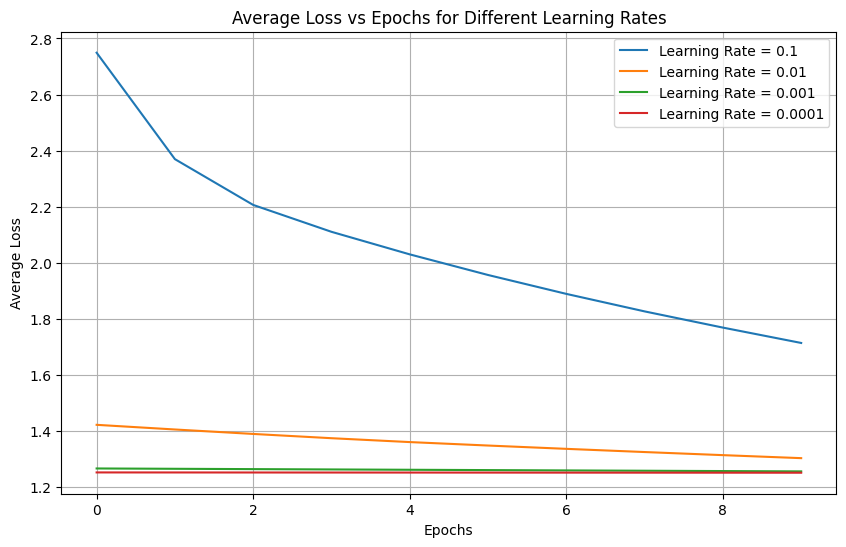

In [225]:
kernel = np.random.randn(3, 3)
fc_weights = np.random.randn(len(flattened), 10)*0.01
fc_bias = np.random.randn(10)*0.01



# Hyperparameters
epochs = 10
learning_rates = [0.1, 0.01, 0.001, 0.0001]
loss_history = {lr: [] for lr in learning_rates}

# Training loop for different learning rates
for learning_rate in learning_rates:
    total_loss = []
    
    for epoch in range(epochs):
        epoch_loss = 0
        
        for idx, (img, label) in enumerate(zip(dataset, labels)):
            # Forward pass
            feature_map = conv2d(img, kernel)
            activated = relu(feature_map)
            pooled = max_pooling(activated)
            flattened = pooled.flatten()
            dense_output = dense_layer(flattened, fc_weights, fc_bias)
            output_layer = softmax(dense_output)
            
            
            # Calculate loss and gradients
            loss_gradient = output_layer - label
            fc_weights_gradient = np.dot(flattened[:, np.newaxis], loss_gradient[np.newaxis, :])
            fc_bias_gradient = loss_gradient
            flattened_gradient = np.dot(fc_weights, loss_gradient)

            # Reshape gradients for pooling
            pooled_gradient = flattened_gradient.reshape(pooled.shape)

            # Backprop through max pooling
            feature_map_gradient = np.zeros_like(activated)
            for i in range(pooled.shape[0]):
                for j in range(pooled.shape[1]):
                    max_val = pooled[i, j]
                    for m in range(2):
                        for n in range(2):
                            orig_x, orig_y = i*2 + m, j*2 + n
                            if orig_x < activated.shape[0] and orig_y < activated.shape[1]:  # Check bounds
                                if activated[orig_x, orig_y] == max_val:
                                    feature_map_gradient[orig_x, orig_y] = pooled_gradient[i, j]

            # Backprop through ReLU
            feature_map_gradient *= np.where(feature_map > 0, 1, 0)

            # Backprop through convolution
            kernel_gradient = np.zeros_like(kernel)
            for i in range(kernel.shape[0]):
                for j in range(kernel.shape[1]):
                    kernel_gradient[i, j] = np.sum(img[i:i+feature_map.shape[0], j:j+feature_map.shape[1]] * feature_map_gradient)

            # Update weights
            fc_weights -= learning_rate * fc_weights_gradient
            fc_bias -= learning_rate * fc_bias_gradient
            kernel -= learning_rate * kernel_gradient

            # Compute loss (cross-entropy)
            loss = -np.sum(label * np.log(output_layer + 1e-9))  # Added small constant to avoid log(0)
            epoch_loss += loss

        # Average loss for this epoch
        avg_loss = epoch_loss / len(dataset)
        total_loss.append(avg_loss)

        # print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")

    # Store the average loss for each learning rate
    loss_history[learning_rate] = total_loss

# Plotting the loss for different learning rates
plt.figure(figsize=(10, 6))
for lr, losses in loss_history.items():
    plt.plot(range(epochs), losses, label=f'Learning Rate = {lr}')

plt.xlabel('Epochs')
plt.ylabel('Average Loss')
plt.title('Average Loss vs Epochs for Different Learning Rates')
plt.legend()
plt.grid(True)
plt.show()


Loss at epoch 200 for kernel 2x2: 2.3476


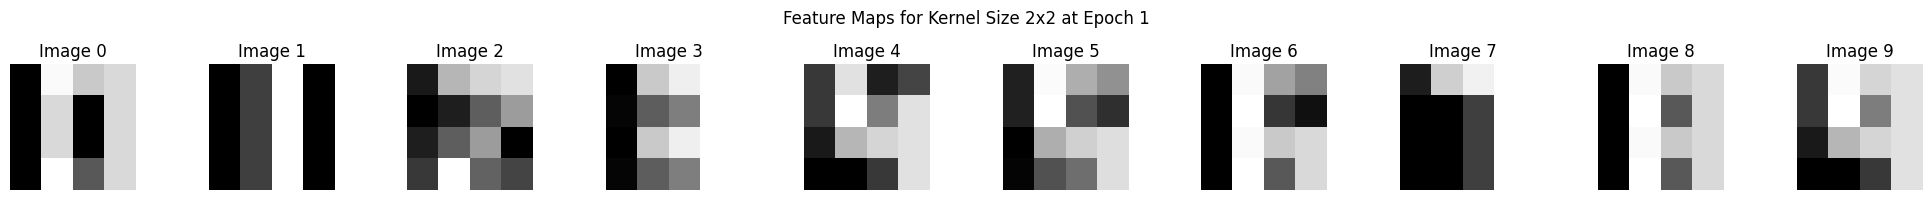

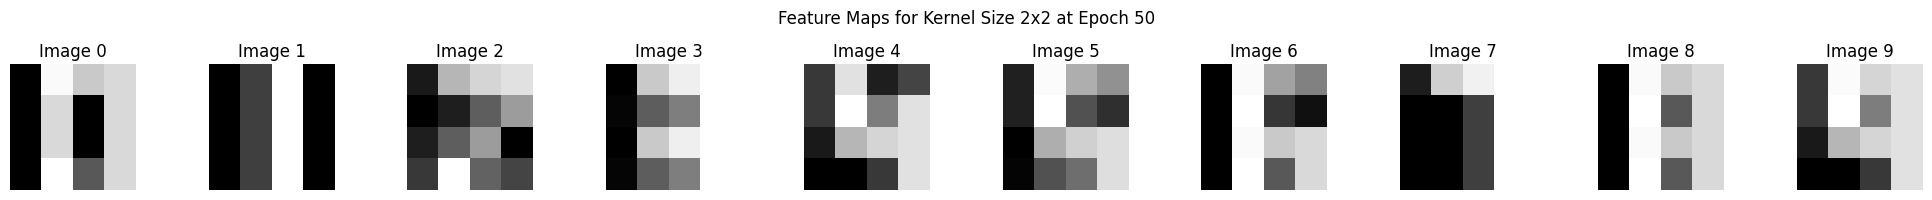

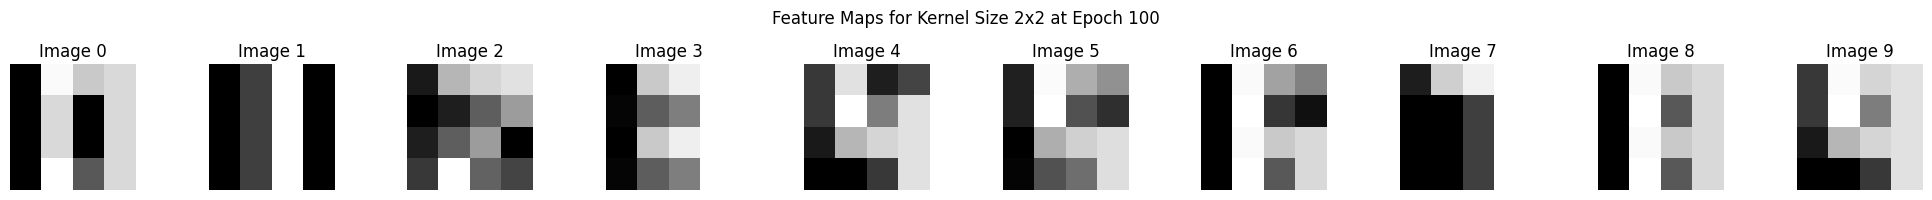

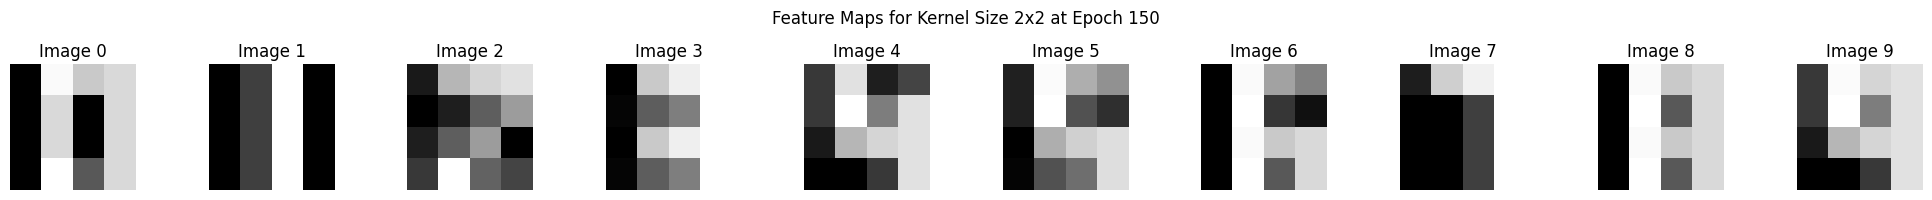

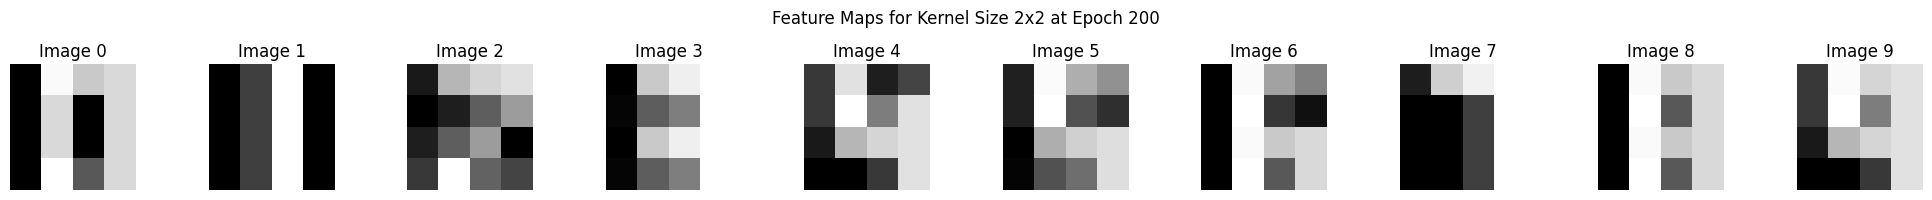

Loss at epoch 200 for kernel 3x3: 0.0453


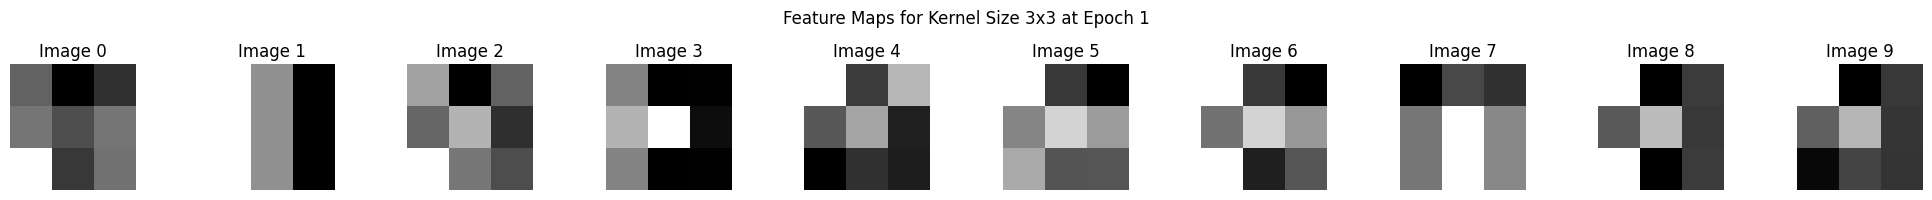

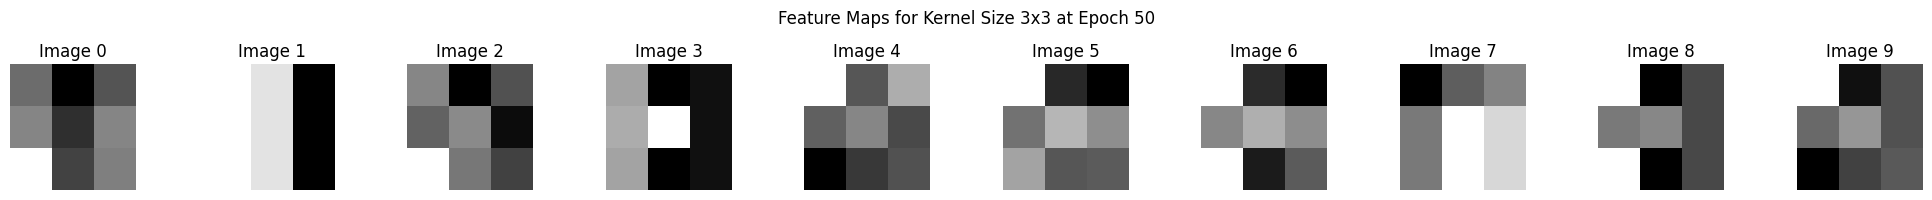

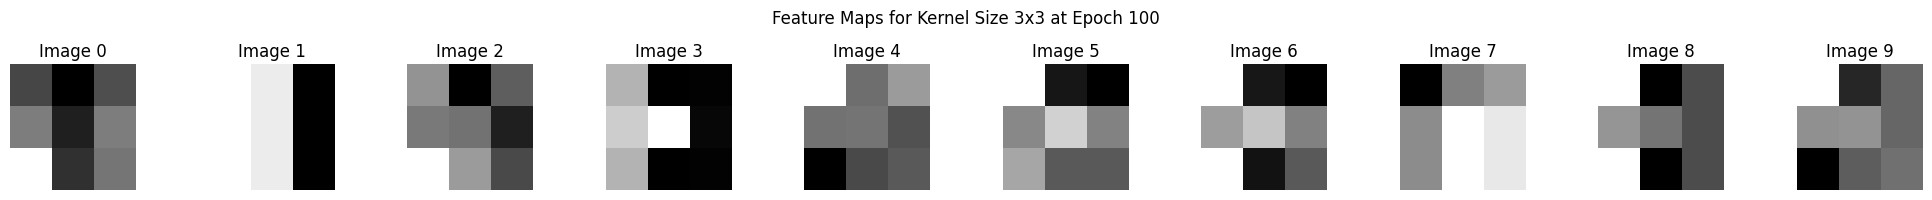

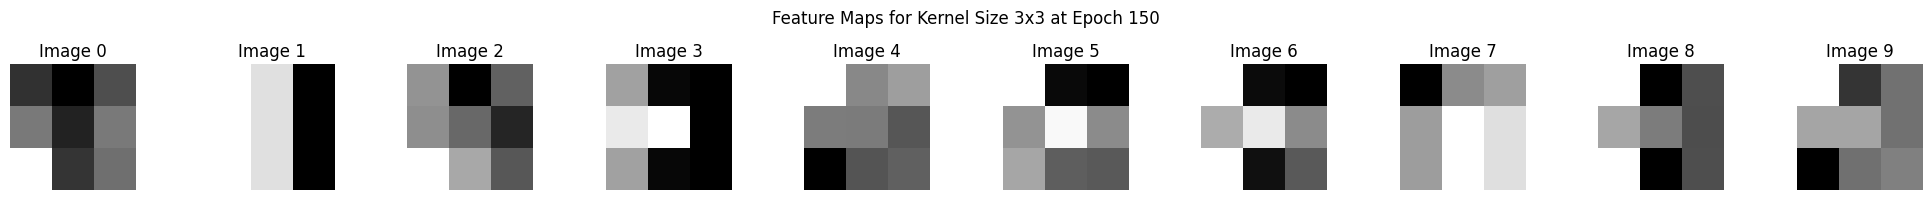

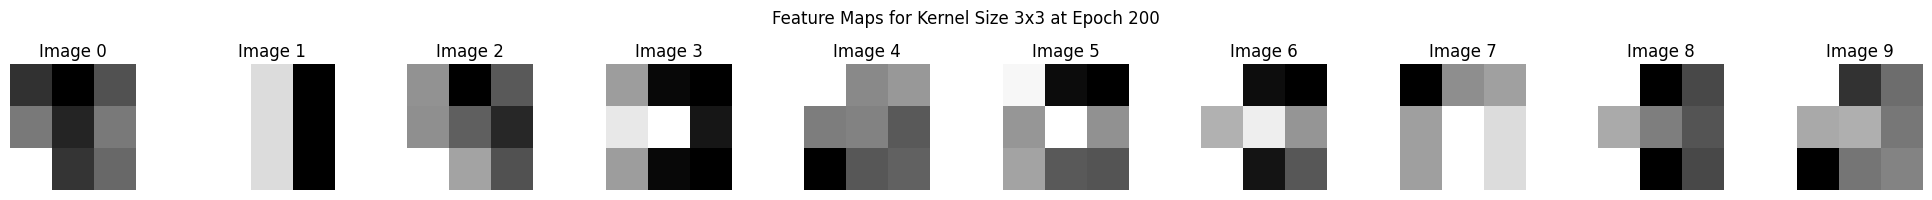

Loss at epoch 200 for kernel 5x5: 0.0033


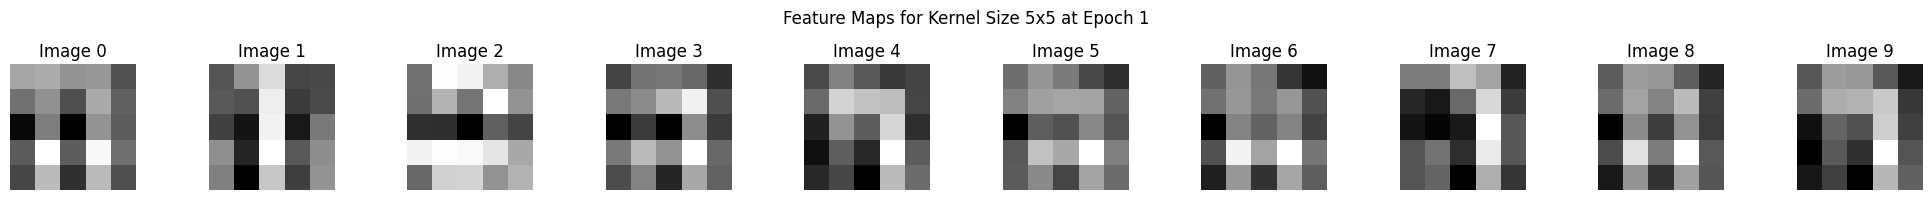

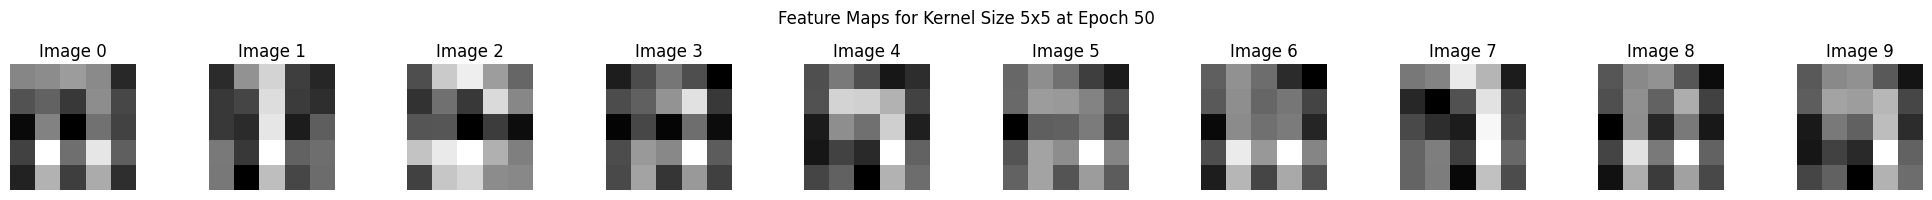

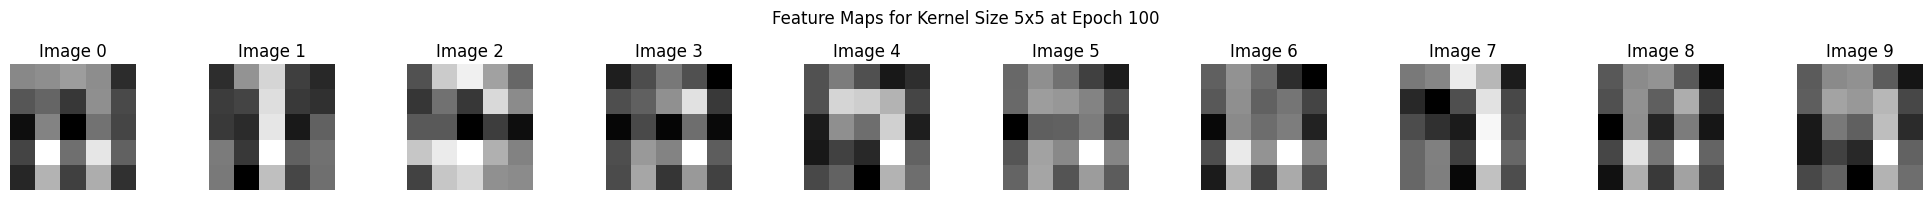

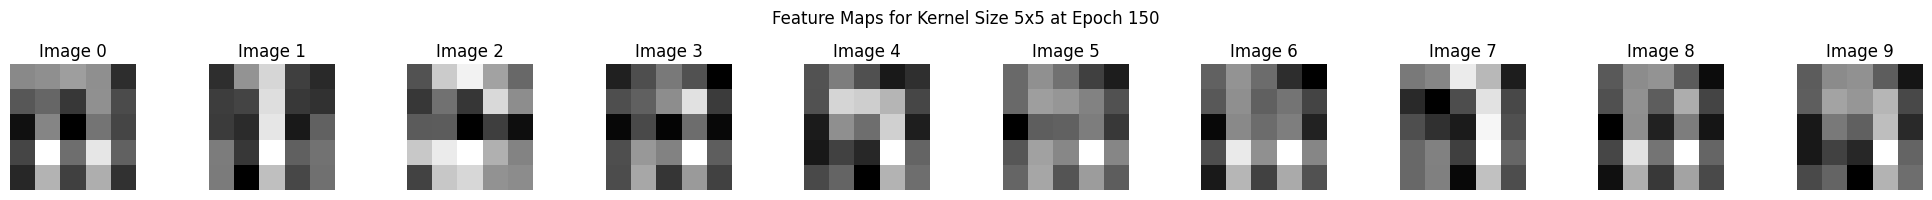

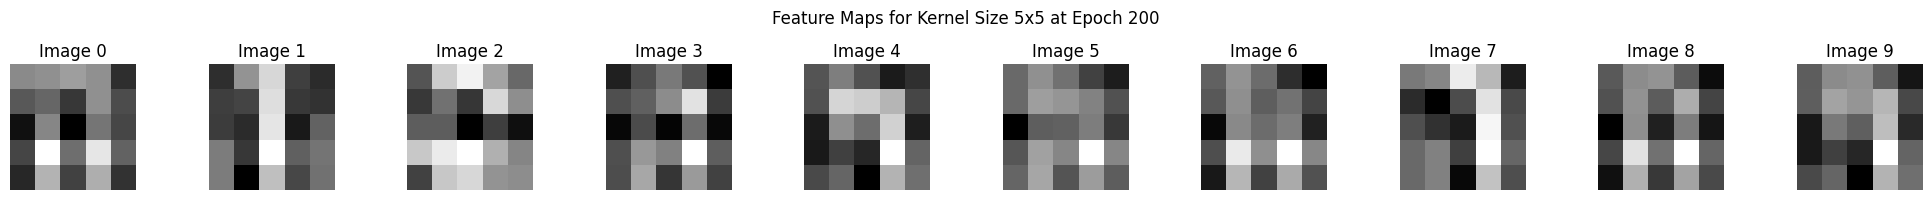

In [226]:
# Initialize network parameters
kernels = {
    '2x2': np.random.randn(2, 2),
    '3x3': np.random.randn(3, 3),
    '5x5': np.random.randn(5, 5)
}

# Hyperparameters
epochs = 200
learning_rate = 0.1

# Tracking loss at different epochs
loss_at_epochs = {1: None, 50: None, 100: None, 150: None, 200: None}
feature_maps_by_epoch = {1: [], 50: [], 100: [], 150: [], 200: []}  # Store feature maps for all images at specified epochs

# Training loop for different kernel sizes
for kernel_size, kernel in kernels.items():
    total_loss = []
    feature_maps_by_epoch = {1: [], 50: [], 100: [], 150: [], 200: []}  # Reset for each kernel size
    
    # Add padding for 5x5 kernel to ensure larger feature map
    pad_size = 2 if kernel_size == '5x5' else 0  # Pad 2 pixels for 5x5 kernel
    expected_flattened_size = flattened.size
    fc_weights = np.random.randn(flattened.size, 10) * 0.01  # Initialize based on flattened size
    fc_bias = np.random.randn(10) * 0.01

    for epoch in range(epochs):
        epoch_loss = 0
        
        for idx, (img, label) in enumerate(zip(dataset, labels)):
            # Forward pass with padding for 5x5 kernel
            padded_img = np.pad(img, ((pad_size, pad_size), (pad_size, pad_size)), mode='constant') if kernel_size == '5x5' else img
            feature_map = conv2d(padded_img, kernel)
            activated = relu(feature_map)
            pooled = max_pooling(activated)
            flattened = pooled.flatten()
            
            # Check if flattened size matches expected size; reinitialize fc_weights if needed
            if flattened.size != expected_flattened_size:
                fc_weights = np.random.randn(flattened.size, 10) * 0.01
                expected_flattened_size = flattened.size
            
            dense_output = dense_layer(flattened, fc_weights, fc_bias)
            output_layer = softmax(dense_output)

            # Calculate loss and gradients
            loss_gradient = output_layer - label
            fc_weights_gradient = np.dot(flattened[:, np.newaxis], loss_gradient[np.newaxis, :])
            fc_bias_gradient = loss_gradient
            flattened_gradient = np.dot(fc_weights, loss_gradient)

            # Reshape gradients for pooling
            pooled_gradient = flattened_gradient.reshape(pooled.shape)

            # Backprop through max pooling
            feature_map_gradient = np.zeros_like(activated)
            for i in range(pooled.shape[0]):
                for j in range(pooled.shape[1]):
                    max_val = pooled[i, j]
                    for m in range(2):
                        for n in range(2):
                            orig_x, orig_y = i*2 + m, j*2 + n
                            if orig_x < activated.shape[0] and orig_y < activated.shape[1]:  # Check bounds
                                if activated[orig_x, orig_y] == max_val:
                                    feature_map_gradient[orig_x, orig_y] = pooled_gradient[i, j]

            # Backprop through ReLU
            feature_map_gradient *= np.where(feature_map > 0, 1, 0)

            # Backprop through convolution
            kernel_gradient = np.zeros_like(kernel)
            for i in range(kernel.shape[0]):
                for j in range(kernel.shape[1]):
                    kernel_gradient[i, j] = np.sum(padded_img[i:i+feature_map.shape[0], j:j+feature_map.shape[1]] * feature_map_gradient)

            # Update weights
            fc_weights -= learning_rate * fc_weights_gradient
            fc_bias -= learning_rate * fc_bias_gradient
            kernel -= learning_rate * kernel_gradient

            # Compute loss (cross-entropy)
            loss = -np.sum(label * np.log(output_layer + 1e-9))  # Added small constant to avoid log(0)
            epoch_loss += loss

            # Store feature maps for all images at specified epochs with debugging for 5x5 kernel
            if epoch + 1 in feature_maps_by_epoch:
                feature_maps_by_epoch[epoch + 1].append(feature_map)

        # Average loss for this epoch
        avg_loss = epoch_loss / len(dataset)
        total_loss.append(avg_loss)

        # Track loss at specified epochs
        if epoch + 1 in loss_at_epochs:
            loss_at_epochs[epoch + 1] = avg_loss

    # Output loss at epoch 200 for each kernel size
    print(f"Loss at epoch 200 for kernel {kernel_size}: {loss_at_epochs[200]:.4f}")

    # Plot feature maps in a grid for all 10 images at each specified epoch
    for epoch in [1, 50, 100, 150, 200]:
        if feature_maps_by_epoch[epoch]:
            fig, axes = plt.subplots(1, 10, figsize=(20, 2))
            for idx, feature_map in enumerate(feature_maps_by_epoch[epoch]):
                if idx < 10:  # Ensure we don't exceed the number of images
                        axes[idx].imshow(feature_map, cmap='gray_r')
                        axes[idx].set_title(f'Image {idx}')
                        axes[idx].axis('off')
            plt.suptitle(f'Feature Maps for Kernel Size {kernel_size} at Epoch {epoch}')
            plt.tight_layout()
            plt.show()

### Task 1

In [ ]:
temp_img = dataset[0]
temp_feature_map = conv2d(temp_img, kernel)
temp_activated = relu(temp_feature_map)
temp_pooled = max_pooling(temp_activated, pool_size=2)
flattened_size = temp_pooled.flatten().shape[0]

fc_weights = np.random.randn(flattened_size, 10) * 0.01
fc_bias = np.random.randn(10) * 0.01


epochs = 10
learning_rate = 0.1

for epoch in range(epochs):
    total_loss = 0

    for idx, (img, label) in enumerate(zip(dataset, labels)):
        
        # Forward
        feature_map  = conv2d(img, kernel)
        activated    = relu(feature_map)
        pooled       = max_pooling(activated, pool_size=2)
        flattened    = pooled.flatten()
        dense_output = dense_layer(flattened, fc_weights, fc_bias)
        output_layer = softmax(dense_output)
        # Forward End
        
        loss_gradient = output_layer - label
        
        #fc_weights_gradient = np.outer(flattened, loss_gradient)
        fc_weights_gradient = np.dot(flattened[:, np.newaxis], loss_gradient[np.newaxis, :])
        fc_bias_gradient    = loss_gradient
        flattened_gradient  = np.dot(fc_weights, loss_gradient)

        # Reshape for pooling layer
        pooled_gradient = flattened_gradient.reshape(pooled.shape)
    
        # Backprop through max pooling
        feature_map_gradient = np.zeros_like(activated)
        for i in range(pooled.shape[0]):
            for j in range(pooled.shape[1]):
                max_val = pooled[i, j]
                for m in range(2):
                    for n in range(2):
                        orig_x, orig_y = i*2 + m, j*2 + n
                        if orig_x < activated.shape[0] and orig_y < activated.shape[1]:  # Check bounds
                            if activated[orig_x, orig_y] == max_val:  # Corrected variable name here
                                feature_map_gradient[orig_x, orig_y] = pooled_gradient[i, j]

        
        # Backprop through ReLU
        feature_map_gradient *= np.where(feature_map > 0, 1, 0)
    
        # Backprop through convolution
        kernel_gradient = np.zeros_like(kernel)
        
        for i in range(kernel.shape[0]):
            for j in range(kernel.shape[1]):
                kernel_gradient[i, j] = np.sum(img[i:i+feature_map.shape[0], j:j+feature_map.shape[1]] * feature_map_gradient)
    
        # Update weights
        fc_weights -= learning_rate * fc_weights_gradient
        fc_bias -= learning_rate * fc_bias_gradient
        kernel -= learning_rate * kernel_gradient

        loss = -np.sum(label * np.log(output_layer + 1e-9))
        total_loss += loss
    
    avg_loss = total_loss / len(dataset)
    print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")
        
print("Updated Kernel:", kernel)

Epoch 1, Loss: 2.3077
Epoch 2, Loss: 2.2664
Epoch 3, Loss: 2.2095
Epoch 4, Loss: 2.1238
Epoch 5, Loss: 2.0055
Epoch 6, Loss: 1.9152
Epoch 7, Loss: 1.8850
Epoch 8, Loss: 1.8538
Epoch 9, Loss: 1.8160
Epoch 10, Loss: 1.7772
Updated Kernel: [[-0.48669715  0.87209326  1.29291077]
 [ 1.23629838 -3.43500234 -1.11425422]
 [ 0.70017758  1.89498976 -3.87058958]]


[0.0038489  0.03930317 0.07495151 0.02460686 0.20263251 0.2525822
 0.00427572 0.01333982 0.35164285 0.03281647]
Predicted: 8 Actual: 5


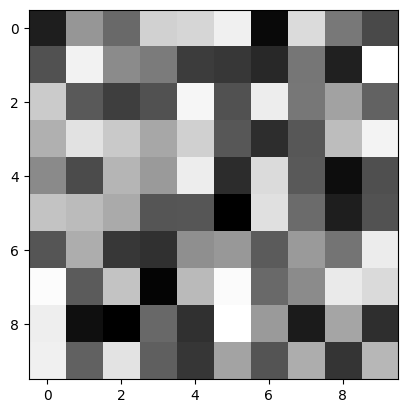

In [ ]:
usethis = 8
test_image = dataset[usethis]
test_label = labels[usethis]
plt.imshow(test_image, cmap='gray_r')
# Forward Pass for Testing
feature_map  = conv2d(test_image, kernel)
activated    = relu(feature_map)
pooled       = max_pooling(activated, pool_size=2)
flattened    = pooled.flatten()
dense_output = dense_layer(flattened, fc_weights, fc_bias)
output_layer = softmax(dense_output)
print(output_layer)
# Predicted class
predicted_class = np.argmax(output_layer)
actual_class    = np.argmax(test_label)
print("Predicted:", predicted_class, "Actual:", actual_class)


In [ ]:
import random
usethis = 2
test_image = dataset[usethis].copy()
test_label = labels[usethis]

# Predict on original image
feature_map = conv2d(test_image, kernel)
activated = relu(feature_map)
pooled = max_pooling(activated, pool_size=2)
flattened = pooled.flatten()
dense_output = dense_layer(flattened, fc_weights, fc_bias)
output_layer = softmax(dense_output)

predicted_class = np.argmax(output_layer)
actual_class = np.argmax(test_label)

print(f"Original - Predicted: {predicted_class}, Actual: {actual_class}")

# Now add random noise
noisy_image = test_image.copy()
for _ in range(2):  # Add 2 noisy pixels
    i = random.randint(0, 4)
    j = random.randint(0, 4)
    noisy_image[i][j] = 1 if noisy_image[i][j] == 0 else 0  # Flip pixel

# Predict on noisy image
feature_map = conv2d(noisy_image, kernel)
activated = relu(feature_map)
pooled = max_pooling(activated, pool_size=2)
flattened = pooled.flatten()
dense_output = dense_layer(flattened, fc_weights, fc_bias)
output_layer = softmax(dense_output)

noisy_predicted_class = np.argmax(output_layer)
print(f"Noisy - Predicted: {noisy_predicted_class}, Actual: {actual_class}")

Original - Predicted: 6, Actual: 0
Noisy - Predicted: 9, Actual: 0


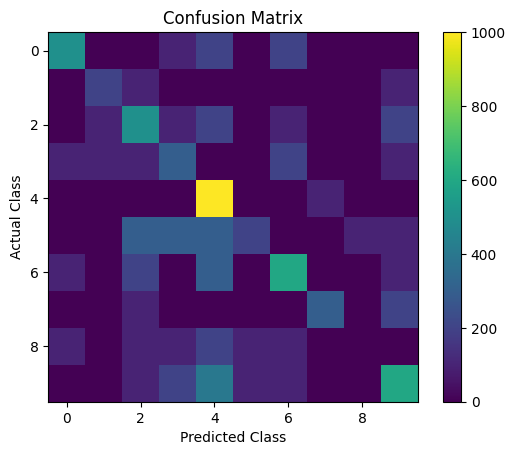

True Positives (TP): 500
False Positives (FP): 300
False Negatives (FN): 500
True Negatives (TN): 8700


In [ ]:
predictions = []
actuals = []

for i in range(100):
    for idx, (test_image, test_label) in enumerate(zip(dataset, labels)):
        # Forward Pass for Testing
        feature_map = conv2d(test_image, kernel)
        activated = relu(feature_map)
        pooled = max_pooling(activated, pool_size=2)
        flattened = pooled.flatten()
        dense_output = dense_layer(flattened, fc_weights, fc_bias)
        output_layer = softmax(dense_output)
        
        # Predicted and actual class
        predicted_class = np.argmax(output_layer)
        actual_class = np.argmax(test_label)
        
        predictions.append(predicted_class)
        actuals.append(actual_class)

# Step 2: Create a random confusion matrix of size 10x10 (for all classes)
confusion_matrix = np.zeros((10, 10), dtype=int)

# Step 3: Update the confusion matrix
for actual, predicted in zip(actuals, predictions):
    confusion_matrix[actual][predicted] += 1

# Step 4: Show the confusion matrix
plt.imshow(confusion_matrix)
plt.title("Confusion Matrix")
plt.colorbar()
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.show()

# Step 5: Compute TP, FP, FN, TN for a 2-class system (positive/negative)
# Let's treat class 0 as "positive" and all others as "negative" for this example
positive_class = 0

# Initialize metrics
TP = confusion_matrix[positive_class][positive_class]  # True Positives
FP = np.sum(confusion_matrix[:, positive_class]) - TP  # False Positives (sum of column - TP)
FN = np.sum(confusion_matrix[positive_class, :]) - TP  # False Negatives (sum of row - TP)
TN = np.sum(confusion_matrix) - (TP + FP + FN)  # True Negatives (total - others)

# Print the results
print(f"True Positives (TP): {TP}")
print(f"False Positives (FP): {FP}")
print(f"False Negatives (FN): {FN}")
print(f"True Negatives (TN): {TN}")

In [229]:
precision = TP / (TP + FP) if (TP + FP) != 0 else 0
recall = TP / (TP + FN) if (TP + FN) != 0 else 0
specificity = TN / (TN + FP) if (TN + FP) != 0 else 0
npv = TN / (TN + FN) if (TN + FN) != 0 else 0
f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) != 0 else 0
accuracy = (TP + TN) / (TP + FP + FN + TN) if (TP + FP + FN + TN) != 0 else 0

print("precision:", precision)
print("recall:", recall)
print("specificity:", specificity)
print("npv:", npv)
print("f1_score:", f1_score)
print("accuracy:", accuracy)

precision: 0.625
recall: 0.5
specificity: 0.9666666666666667
npv: 0.9456521739130435
f1_score: 0.5555555555555556
accuracy: 0.92


In [231]:
kernel = np.random.randn(3, 3)  # Initialize kernel here (or load it)
temp_img = dataset[0]  # Use a sample image
temp_feature_map = conv2d(temp_img, kernel)
temp_activated = relu(temp_feature_map)
temp_pooled = max_pooling(temp_activated, pool_size=2)
flattened_size = temp_pooled.flatten().shape[0]

fc_weights = np.random.randn(flattened_size, 10) * 0.01
fc_bias = np.random.randn(10) * 0.01

def evaluate_model_with_noise(dataset, labels, noise_level):
    confusion_matrix = np.zeros((10, 10), dtype=int)

    for _ in range(1000):
        idx = np.random.randint(0, 10)
        test_image = np.copy(dataset[idx])  # Avoid modifying the original
        test_label = labels[idx]

        # Add noise: flip or set pixels to 1 at random positions
        for _ in range(noise_level):
            x = random.randint(0, test_image.shape[0] - 1)
            y = random.randint(0, test_image.shape[1] - 1)
            test_image[x][y] = 1  # Add noise

        feature_map = conv2d(test_image, kernel)
        activated = relu(feature_map)
        pooled = max_pooling(activated, pool_size=2)
        flattened = pooled.flatten()
        dense_output = dense_layer(flattened, fc_weights, fc_bias)
        output_layer = softmax(dense_output)

        predicted_class = np.argmax(output_layer)
        actual_class = np.argmax(test_label)
        confusion_matrix[actual_class][predicted_class] += 1

    # Metrics calculation
    num_classes = confusion_matrix.shape[0]
    tp = fp = fn = tn = 0

    for cls in range(num_classes):
        tp_tmp = confusion_matrix[cls][cls]
        fp_tmp = confusion_matrix[:, cls].sum() - tp_tmp
        fn_tmp = confusion_matrix[cls, :].sum() - tp_tmp
        tn_tmp = confusion_matrix.sum() - (tp_tmp + fp_tmp + fn_tmp)
        tp += tp_tmp
        fp += fp_tmp
        fn += fn_tmp
        tn += tn_tmp

    precision = tp / (tp + fp) if (tp + fp) != 0 else 0
    recall = tp / (tp + fn) if (tp + fn) != 0 else 0
    accuracy = (tp + tn) / (tp + tn + fp + fn)

    return accuracy, precision, recall


# Collect results for different noise levels
results = []

for noise_level in range(5):  # Noise levels from 0 to 4
    acc, prec, rec = evaluate_model_with_noise(dataset, labels, noise_level)
    results.append((noise_level, acc, prec, rec))

# Print the table
print("{:<12} {:<10} {:<10} {:<10}".format("Noise Level", "Accuracy", "Precision", "Recall"))
print("-" * 45)
for noise_level, acc, prec, rec in results:
    print("{:<12} {:.4f}     {:.4f}     {:.4f}".format(noise_level, acc, prec, rec))


Noise Level  Accuracy   Precision  Recall    
---------------------------------------------
0            0.8230     0.1150     0.1150
1            0.8208     0.1040     0.1040
2            0.8192     0.0960     0.0960
3            0.8188     0.0940     0.0940
4            0.8180     0.0900     0.0900


### Task 2: Adding an additional Kernel

In [232]:
# Helper functions
def conv2d1(image, kernel):
    img_h, img_w = image.shape
    k_h, k_w = kernel.shape
    out_h, out_w = img_h - k_h + 1, img_w - k_w + 1
    output = np.zeros((out_h, out_w))
    for i in range(out_h):
        for j in range(out_w):
            output[i, j] = np.sum(image[i:i+k_h, j:j+k_w] * kernel)
    return output

def relu1(x):
    return np.maximum(0, x)

def max_pooling1(image, pool_size=2):
    image_height, image_width = image.shape
    output_height = (image_height + pool_size - 1) // pool_size
    output_width = (image_width + pool_size - 1) // pool_size
    output = np.zeros((output_height, output_width))
    for i in range(output_height):
        for j in range(output_width):
            start_i = i * pool_size
            start_j = j * pool_size
            end_i = min(start_i + pool_size, image_height)
            end_j = min(start_j + pool_size, image_width)
            region = image[start_i:end_i, start_j:end_j]
            output[i, j] = np.max(region)
    return output

def softmax1(x):
    exp_x = np.exp(x - np.max(x))
    return exp_x / np.sum(exp_x)

def dense_layer1(inputs, weights, bias):
    return np.dot(inputs, weights) + bias

# CNN parameters
image_size = 5
kernel_size = 3
pool_size = 2
conv_output_size = image_size - kernel_size + 1  # 5-3+1=3
pool_output_size = (conv_output_size + pool_size - 1) // pool_size  # (3+2-1)//2=2
flattened_size = 2 * pool_output_size * pool_output_size  # 2*2*2=8

# Initialize parameters
kernel1 = np.random.randn(kernel_size, kernel_size) * 0.01
kernel2 = np.random.randn(kernel_size, kernel_size) * 0.01
fc_weights = np.random.randn(flattened_size, 10) * 0.01  # Shape: (8, 10)
fc_bias = np.random.randn(10) * 0.01

epochs = 10
learning_rate = 0.1

# Training loop
for epoch in range(epochs):
    total_loss = 0
    for idx, (img, label) in enumerate(zip(dataset, labels)):
        # Forward pass
        feature_map1 = conv2d1(img, kernel1)
        feature_map2 = conv2d1(img, kernel2)
        activated1 = relu1(feature_map1)
        activated2 = relu1(feature_map2)
        pooled1 = max_pooling1(activated1, pool_size=pool_size)
        pooled2 = max_pooling1(activated2, pool_size=pool_size)
        flattened = np.concatenate([pooled1.flatten(), pooled2.flatten()])
        dense_output = dense_layer1(flattened, fc_weights, fc_bias)
        output_layer = softmax1(dense_output)

        # Compute loss
        loss = -np.sum(label * np.log(output_layer + 1e-9))
        total_loss += loss

        # Backward pass
        loss_gradient = output_layer - label

        # Backprop through dense layer
        fc_weights_gradient = np.dot(flattened[:, np.newaxis], loss_gradient[np.newaxis, :])
        fc_bias_gradient = loss_gradient
        flattened_gradient = np.dot(fc_weights, loss_gradient)

        # Split flattened gradient
        flattened_size_per_map = flattened_size // 2
        pooled_gradient1 = flattened_gradient[:flattened_size_per_map].reshape(pooled1.shape)
        pooled_gradient2 = flattened_gradient[flattened_size_per_map:].reshape(pooled2.shape)

        # Backprop through max pooling
        feature_map_gradient1 = np.zeros_like(activated1)
        feature_map_gradient2 = np.zeros_like(activated2)
        for i in range(pooled1.shape[0]):
            for j in range(pooled1.shape[1]):
                region1 = activated1[i*pool_size:(i+1)*pool_size, j*pool_size:(j+1)*pool_size]
                region2 = activated2[i*pool_size:(i+1)*pool_size, j*pool_size:(j+1)*pool_size]
                max_idx1 = np.unravel_index(np.argmax(region1), region1.shape)
                max_idx2 = np.unravel_index(np.argmax(region2), region2.shape)
                feature_map_gradient1[i*pool_size + max_idx1[0], j*pool_size + max_idx1[1]] = pooled_gradient1[i, j]
                feature_map_gradient2[i*pool_size + max_idx2[0], j*pool_size + max_idx2[1]] = pooled_gradient2[i, j]

        # Backprop through ReLU
        feature_map_gradient1 *= np.where(feature_map1 > 0, 1, 0)
        feature_map_gradient2 *= np.where(feature_map2 > 0, 1, 0)

        # Backprop through convolution
        kernel_gradient1 = np.zeros_like(kernel1)
        kernel_gradient2 = np.zeros_like(kernel2)
        for i in range(kernel_size):
            for j in range(kernel_size):
                kernel_gradient1[i, j] = np.sum(
                    img[i:i+conv_output_size, j:j+conv_output_size] * feature_map_gradient1
                )
                kernel_gradient2[i, j] = np.sum(
                    img[i:i+conv_output_size, j:j+conv_output_size] * feature_map_gradient2
                )

        # Update weights
        fc_weights -= learning_rate * fc_weights_gradient
        fc_bias -= learning_rate * fc_bias_gradient
        kernel1 -= learning_rate * kernel_gradient1
        kernel2 -= learning_rate * kernel_gradient2

    avg_loss = total_loss / len(dataset)
    print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")

print("Updated Kernel 1:\n", kernel1)
print("Updated Kernel 2:\n", kernel2)

Epoch 1, Loss: 2.3473
Epoch 2, Loss: 2.3472
Epoch 3, Loss: 2.3471
Epoch 4, Loss: 2.3471
Epoch 5, Loss: 2.3470
Epoch 6, Loss: 2.3470
Epoch 7, Loss: 2.3469
Epoch 8, Loss: 2.3468
Epoch 9, Loss: 2.3466
Epoch 10, Loss: 2.3463
Updated Kernel 1:
 [[ 0.02758077  0.00190909 -0.01481845]
 [-0.0009802  -0.01984015 -0.00597279]
 [-0.00997995  0.00983172 -0.01394188]]
Updated Kernel 2:
 [[ 0.00250707  0.03050815  0.0565387 ]
 [-0.02055702 -0.02866108 -0.0042742 ]
 [-0.01502003 -0.01571155 -0.0551257 ]]


In [233]:
def evaluate_model_with_noise1(dataset, labels, kernel1, kernel2, fc_weights, fc_bias, noise_level):
    confusion_matrix = np.zeros((10, 10), dtype=int)

    for _ in range(1000):
        idx = np.random.randint(0, 10)
        test_image = np.copy(dataset[idx])  # Avoid modifying the original
        test_label = labels[idx]

        # Add noise: set pixels to 1 at random positions
        for _ in range(noise_level):
            x = random.randint(0, test_image.shape[0] - 1)
            y = random.randint(0, test_image.shape[1] - 1)
            test_image[x][y] = 1  # Add noise

        # Forward pass with two kernels
        feature_map1 = conv2d(test_image, kernel1)
        feature_map2 = conv2d(test_image, kernel2)
        activated1 = relu(feature_map1)
        activated2 = relu(feature_map2)
        pooled1 = max_pooling(activated1, pool_size=2)
        pooled2 = max_pooling(activated2, pool_size=2)
        flattened = np.concatenate([pooled1.flatten(), pooled2.flatten()])
        dense_output = dense_layer(flattened, fc_weights, fc_bias)
        output_layer = softmax(dense_output)

        predicted_class = np.argmax(output_layer)
        actual_class = np.argmax(test_label)
        confusion_matrix[actual_class][predicted_class] += 1

    # Metrics calculation
    num_classes = confusion_matrix.shape[0]
    tp = fp = fn = tn = 0

    for cls in range(num_classes):
        tp_tmp = confusion_matrix[cls][cls]
        fp_tmp = confusion_matrix[:, cls].sum() - tp_tmp
        fn_tmp = confusion_matrix[cls, :].sum() - tp_tmp
        tn_tmp = confusion_matrix.sum() - (tp_tmp + fp_tmp + fn_tmp)
        tp += tp_tmp
        fp += fp_tmp
        fn += fn_tmp
        tn += tn_tmp

    precision = tp / (tp + fp) if (tp + fp) != 0 else 0
    recall = tp / (tp + fn) if (tp + fn) != 0 else 0
    accuracy = (tp + tn) / (tp + tn + fp + fn)

    return accuracy, precision, recall

In [234]:
# Collect results for different noise levels
results = []

for noise_level in range(5):  # Noise levels from 0 to 4
    acc, prec, rec = evaluate_model_with_noise1(dataset, labels, kernel1, kernel2, fc_weights, fc_bias, noise_level)
    results.append((noise_level, acc, prec, rec))

# Print results without table formatting
for noise_level, acc, prec, rec in results:
    print(f"Noise Level {noise_level}: Accuracy={acc:.4f}, Precision={prec:.4f}, Recall={rec:.4f}")

Noise Level 0: Accuracy=0.8192, Precision=0.0960, Recall=0.0960
Noise Level 1: Accuracy=0.8230, Precision=0.1150, Recall=0.1150
Noise Level 2: Accuracy=0.8178, Precision=0.0890, Recall=0.0890
Noise Level 3: Accuracy=0.8196, Precision=0.0980, Recall=0.0980
Noise Level 4: Accuracy=0.8202, Precision=0.1010, Recall=0.1010
